# 1 — Clustering greenhouse states: *what goes together?*

**Goal of this notebook.** Before we predict interior temperature and humidity, we want to understand the *recurring situations* the greenhouse lives through — e.g. *cold closed winter nights*, *hot sunny days with the vents open*, *humid days running the fog system*. Each hour of data is a snapshot of the whole greenhouse (interior climate + which actuators are running + outside weather). Clustering groups these snapshots so that hours **that normally go together** get the same label.

That label (the **cluster / regime**) is then saved to disk and used in notebook&nbsp;2 as an extra input feature for the prediction models.

**Why this is a valid model input (no data leakage).** We cluster *only* on information available **at the moment of prediction** — the current sensor readings, current actuator states, outside weather and time of day. We never let the clustering see the *future* temperature/humidity we are trying to predict. So the cluster of hour *t* is known at time *t* and is safe to feed to a forecaster.

**Pipeline**
1. Assemble one tidy hourly table (shared `greenhouse_dataset.py` module).
2. Pick the "state" features and standardise them.
3. Choose the number of clusters *k* (elbow + silhouette).
4. Fit K-Means, inspect and interpret the regimes.
5. Visualise (PCA map, temperature–humidity map, daily rhythm, timeline).
6. Save the cluster labels for notebook&nbsp;2.

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from greenhouse_dataset import (
    build_hourly_dataset,
    CONTINUOUS_COLS, ACTUATOR_COLS, EXTERIOR_COLS,
)

pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (10, 4)

## 1.1 — Load the assembled hourly dataset

`build_hourly_dataset()` merges every interior sensor, every actuator, the exterior weather station and the Open-Meteo forecast onto a single regular **hourly** index. See `greenhouse_dataset.py` for the exact merge / gap-filling rules (actuators → missing means *off*; continuous sensors → short gaps interpolated).

In [3]:
df = build_hourly_dataset(root=".")
print("shape:", df.shape)
print("time span:", df.index.min(), "->", df.index.max())
df.head()

shape: (4655, 42)
time span: 2026-01-01 00:00:00 -> 2026-07-13 22:00:00


,temp_alta,temp_baja,temp_centro,hum_alta,hum_baja,hum_centro,pres_baro_alta,pres_baro_baja,pres_baro_centro,pres_vapor_alta,...,fc_hum,fc_precip,fc_viento,fc_rad,hour_sin,hour_cos,doy_sin,doy_cos,hour,month
time,,,,,,,,,,,,,,,,,,,,,
2026-01-01 00:00:00,10.341026,10.583333,NaN,86.956522,85.833333,NaN,100.912083,100.974500,NaN,1.090500,...,96.957270,0.0,0.509902,0.0,0.000000,1.000000,0.017213,0.999852,0,1
2026-01-01 01:00:00,9.473810,9.683333,NaN,87.777778,86.722222,NaN,100.890000,100.955652,NaN,1.045333,...,97.286970,0.0,0.806226,0.0,0.258819,0.965926,0.017213,0.999852,1,1
2026-01-01 02:00:00,8.741667,9.092500,NaN,87.500000,86.071429,NaN,100.871818,100.940952,NaN,0.986667,...,98.968315,0.0,0.585235,0.0,0.500000,0.866025,0.017213,0.999852,2,1
2026-01-01 03:00:00,8.006977,8.264444,NaN,88.736842,87.312500,NaN,100.830500,100.902500,NaN,0.948889,...,98.624320,0.0,0.894427,0.0,0.707107,0.707107,0.017213,0.999852,3,1
2026-01-01 04:00:00,8.668571,8.829730,NaN,90.263158,89.250000,NaN,100.805294,100.877222,NaN,1.009615,...,99.305330,0.0,0.860233,0.0,0.866025,0.500000,0.017213,0.999852,4,1


## 1.2 — Choose the clustering features

We describe each hour by its **state**, grouped into four families:

* **Interior climate** — the temperatures, humidities, pressures, radiation and wind measured inside the greenhouse (high/middle/low positions).
* **Actuators** — minutes-per-hour each device ran (heaters, fog, blowers, recirculators, shade screens, roof & side vents).
* **Exterior weather** — outside temperature, humidity, radiation and wind.
* **Time of day** — a cyclic (sine/cosine) encoding of the hour, so 23:00 and 00:00 are treated as neighbours.

We deliberately **exclude** the future targets. Rows with any missing state value are dropped for the clustering step only.

In [4]:
time_feats = ["hour_sin", "hour_cos", "doy_sin", "doy_cos"]
cluster_features = CONTINUOUS_COLS + ACTUATOR_COLS + EXTERIOR_COLS + time_feats

C = df[cluster_features].dropna()
print(f"{C.shape[0]} complete hourly snapshots, {C.shape[1]} features")
print("kept span:", C.index.min(), "->", C.index.max())

3659 complete hourly snapshots, 35 features
kept span: 2026-01-21 10:00:00 -> 2026-07-13 22:00:00


## 1.3 — Standardise

K-Means uses Euclidean distance, so features must share a scale — otherwise pressure (~1000&nbsp;mbar) would dominate temperature (~25&nbsp;°C). We z-score every feature (mean&nbsp;0, std&nbsp;1).

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(C)
print("standardised matrix:", X.shape)

standardised matrix: (3659, 35)


## 1.4 — How many clusters?

Two complementary diagnostics:

* **Elbow (inertia)** — within-cluster spread; look for the *k* where the curve stops dropping steeply.
* **Silhouette** — how well separated the clusters are (higher = better, range −1…1).

There is rarely one "correct" *k*; we balance the diagnostics against **interpretability**.

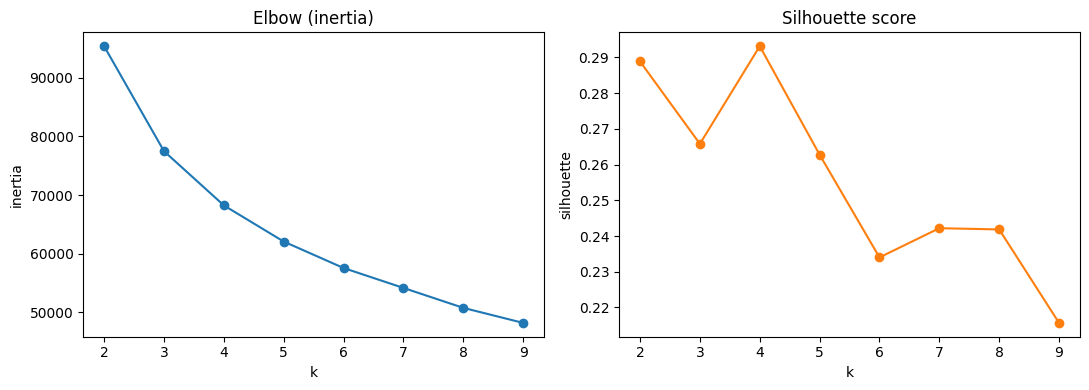

k=2: silhouette=0.289
k=3: silhouette=0.266
k=4: silhouette=0.293
k=5: silhouette=0.263
k=6: silhouette=0.234
k=7: silhouette=0.242
k=8: silhouette=0.242
k=9: silhouette=0.216


In [6]:
ks = range(2, 10)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_, sample_size=2000, random_state=0))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(ks), inertias, "o-"); ax[0].set_title("Elbow (inertia)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("inertia")
ax[1].plot(list(ks), sils, "o-", color="C1"); ax[1].set_title("Silhouette score")
ax[1].set_xlabel("k"); ax[1].set_ylabel("silhouette")
plt.tight_layout(); plt.show()

for k, s in zip(ks, sils):
    print(f"k={k}: silhouette={s:.3f}")

**Reading the plots.** The silhouette is highest at very small *k*, but *k*&nbsp;=&nbsp;2–3 only splits "cold vs warm" — far too coarse to steer the greenhouse with. Because we want to use these clusters for **control** (target a temperature/humidity, then see which *operating state* delivers it), we deliberately favour **granularity and interpretability over the raw silhouette** and pick **k&nbsp;=&nbsp;8**. That gives eight reasonably-sized, distinguishable operating states while each is still large enough to describe reliably. `K` is a single knob below — raise it for finer targeting, lower it for broader regimes.

In [7]:
K = 8
kmeans = KMeans(n_clusters=K, n_init=10, random_state=0).fit(X)
clusters = pd.Series(kmeans.labels_, index=C.index, name="cluster")
clusters.value_counts().sort_index()

cluster
0    749
1    985
2    416
3    193
4    507
5    595
6      3
7    211
Name: count, dtype: int64

## 1.5 — Interpret the operating states (control view)

For control we read each cluster as an **operating state**: *"when the greenhouse is in this state, temperature and humidity sit here, and these systems are typically running."* The table below is sorted by temperature so you can scan from cold to hot states; the actuator columns are the average minutes-per-hour each climatic system runs in that state.

In [8]:
climate_cols = ["temp_centro", "hum_centro", "ext_temp", "ext_rad_par"]
act_cols = ["act_calefactores", "act_fog", "act_bomba_soplante", "act_recirculador",
            "act_pantalla_cenital", "act_vent_cen_este", "act_vent_lat_norte",
            "act_vent_lat_sur"]
profile = C.groupby(clusters)[climate_cols + act_cols].mean()
profile["med_hour"] = df.loc[C.index].assign(c=clusters).groupby("c")["hour"].median()
profile["n_hours"] = clusters.value_counts().sort_index()
profile = profile.sort_values("temp_centro")
profile.round(1)

,temp_centro,hum_centro,ext_temp,ext_rad_par,act_calefactores,act_fog,act_bomba_soplante,act_recirculador,act_pantalla_cenital,act_vent_cen_este,act_vent_lat_norte,act_vent_lat_sur,med_hour,n_hours
cluster,,,,,,,,,,,,,,
1,14.6,72.0,14.3,10.8,3.0,0.0,0.0,1.1,0.0,0.2,0.4,0.0,6.0,985
5,15.8,62.7,15.2,21.8,0.3,0.0,0.0,0.1,0.0,0.0,0.0,0.0,11.0,595
4,24.4,70.1,25.6,11.4,0.1,0.0,0.0,15.4,1.9,10.2,9.3,0.6,19.0,507
6,25.1,51.2,22.5,217.3,0.0,0.2,50.0,0.0,42.7,26.8,33.9,18.9,7.0,3
7,25.2,67.3,25.1,92.9,2.8,0.3,0.0,31.2,12.1,31.7,55.0,54.2,6.0,211
3,29.6,48.9,28.2,369.0,1.0,1.3,0.0,52.1,56.1,46.1,52.4,8.1,10.0,193
0,29.8,33.1,20.9,240.8,0.0,0.0,0.0,4.3,0.6,0.2,0.7,0.6,13.0,749
2,33.7,61.1,34.2,383.1,0.0,2.6,0.0,59.4,56.6,1.7,22.8,0.7,13.0,416


**How to read it for control.** Each row is a state you could aim for:

* the **cold** rows (low `temp_centro`, night `med_hour`, `act_calefactores` > 0) are *winter/night, heating on, closed up*;
* the **hot** rows (high `temp_centro`, midday, vents + screens active) are *summer peak, actively ventilating/shading*;
* rows with high `act_fog` are *humidifying / evaporative-cooling* states.

So if your goal were, say, ~24 °C at ~70 % RH, you would look for the state whose `temp_centro`/`hum_centro` sit closest to that and read off the actuator pattern that accompanies it (done explicitly in 1.5b). ⚠️ **This is descriptive, not causal** — it shows the settings that *co-occur* with those readings, not proof that those settings *cause* them. The what-if notebook (3) tackles the causal "if I change this, what happens" question.

### 1.5b — Target lookup: which state matches a desired climate?

A small helper that, given a desired temperature and humidity, returns the operating state whose average climate is closest — and the actuator pattern that characterises it. This is the first, descriptive bridge from clustering toward regulation.

In [9]:
def nearest_state(target_temp, target_hum):
    d = ((profile["temp_centro"] - target_temp) ** 2
         + (profile["hum_centro"] - target_hum) ** 2) ** 0.5
    best = d.idxmin()
    print(f"target {target_temp} °C / {target_hum} %  ->  closest state = cluster {best}")
    print(profile.loc[best, ["temp_centro", "hum_centro"] + act_cols].round(1))
    return best

_ = nearest_state(24, 70)

target 24 °C / 70 %  ->  closest state = cluster 4
temp_centro             24.4
hum_centro              70.1
act_calefactores         0.1
act_fog                  0.0
act_bomba_soplante       0.0
act_recirculador        15.4
act_pantalla_cenital     1.9
act_vent_cen_este       10.2
act_vent_lat_norte       9.3
act_vent_lat_sur         0.6
Name: 4, dtype: float64


## 1.6 — Visualise the clusters

**(a) PCA map.** Project the high-dimensional standardised state onto its first two principal components just for plotting, and colour by cluster.

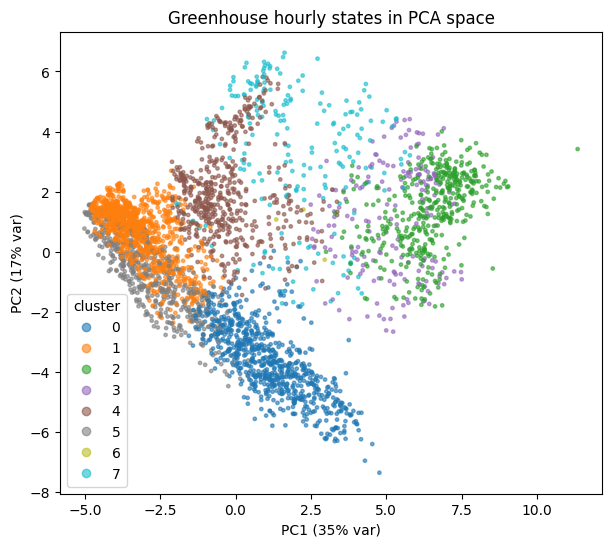

In [13]:
pca = PCA(n_components=2, random_state=0)
XY = pca.fit_transform(X)
plt.figure(figsize=(7, 6))
sc = plt.scatter(XY[:, 0], XY[:, 1], c=clusters.values, cmap="tab10", s=6, alpha=0.6)
plt.legend(*sc.legend_elements(), title="cluster")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
plt.title("Greenhouse hourly states in PCA space"); plt.show()

**(b) Temperature–humidity map.** The two variables we ultimately predict, coloured by regime — this is the most intuitive view of "what goes together".

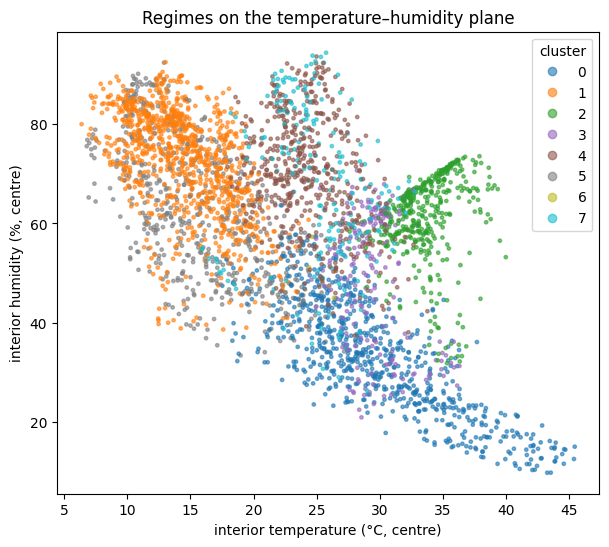

In [11]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(C["temp_centro"], C["hum_centro"], c=clusters.values,
                 cmap="tab10", s=6, alpha=0.6)
plt.legend(*sc.legend_elements(), title="cluster")
plt.xlabel("interior temperature (°C, centre)")
plt.ylabel("interior humidity (%, centre)")
plt.title("Regimes on the temperature–humidity plane"); plt.show()

**(c) Daily rhythm.** How each regime is distributed across the 24 hours of the day.

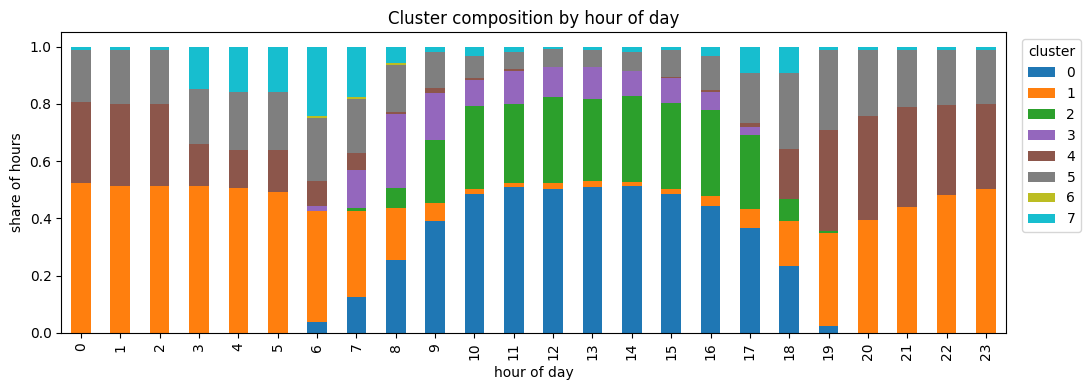

In [12]:
ch = pd.crosstab(df.loc[C.index, "hour"], clusters, normalize="index")
ch.plot(kind="bar", stacked=True, colormap="tab10", figsize=(11, 4))
plt.ylabel("share of hours"); plt.xlabel("hour of day")
plt.title("Cluster composition by hour of day")
plt.legend(title="cluster", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

In [13]:
profile.round(1)

,temp_centro,hum_centro,ext_temp,ext_rad_par,act_calefactores,act_fog,act_bomba_soplante,act_recirculador,act_pantalla_cenital,act_vent_cen_este,act_vent_lat_norte,act_vent_lat_sur,med_hour,n_hours
cluster,,,,,,,,,,,,,,
1,14.6,72.0,14.3,10.8,3.0,0.0,0.0,1.1,0.0,0.2,0.4,0.0,6.0,985
5,15.8,62.7,15.2,21.8,0.3,0.0,0.0,0.1,0.0,0.0,0.0,0.0,11.0,595
4,24.4,70.1,25.6,11.4,0.1,0.0,0.0,15.4,1.9,10.2,9.3,0.6,19.0,507
6,25.1,51.2,22.5,217.3,0.0,0.2,50.0,0.0,42.7,26.8,33.9,18.9,7.0,3
7,25.2,67.3,25.1,92.9,2.8,0.3,0.0,31.2,12.1,31.7,55.0,54.2,6.0,211
3,29.6,48.9,28.2,369.0,1.0,1.3,0.0,52.1,56.1,46.1,52.4,8.1,10.0,193
0,29.8,33.1,20.9,240.8,0.0,0.0,0.0,4.3,0.6,0.2,0.7,0.6,13.0,749
2,33.7,61.1,34.2,383.1,0.0,2.6,0.0,59.4,56.6,1.7,22.8,0.7,13.0,416


**(d) Timeline.** The regime the greenhouse is in over the whole recorded period — you should see the seasonal drift from winter to summer regimes.

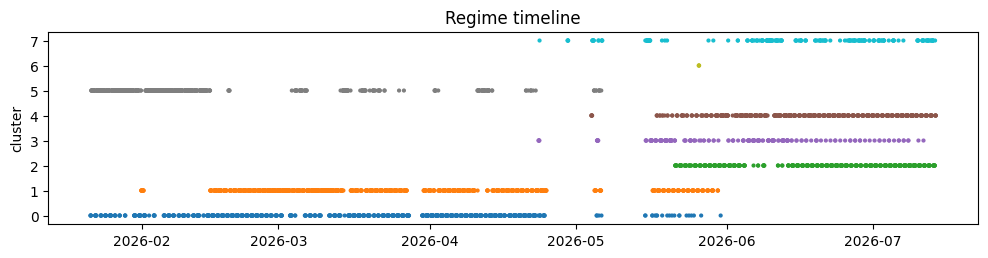

In [14]:
plt.figure(figsize=(12, 2.5))
plt.scatter(clusters.index, clusters.values, c=clusters.values, cmap="tab10", s=4)
plt.yticks(range(K)); plt.ylabel("cluster"); plt.title("Regime timeline"); plt.show()

## 1.7 — Save the labels for notebook 2

We persist the cluster label of every hour so the prediction notebook can join it as an input feature. We also save the fitted scaler + K-Means so the exact same assignment can be reproduced on new data.

In [15]:
import os, joblib
os.makedirs("model data", exist_ok=True)
clusters.rename("cluster").to_frame().to_csv("model data/clusters.csv")
joblib.dump({"scaler": scaler, "kmeans": kmeans, "features": cluster_features},
            "model data/cluster_model.joblib")
print("saved -> model data/clusters.csv  (", len(clusters), "labelled hours )")
print("saved -> model data/cluster_model.joblib")

saved -> model data/clusters.csv  ( 3659 labelled hours )
saved -> model data/cluster_model.joblib


## Summary

* Each greenhouse hour was described by its interior climate, actuator activity, exterior weather and time of day.
* K-Means (**k = 8**) grouped these into eight recurring, interpretable **operating states**, each with a characteristic temperature/humidity and actuator pattern — a granularity chosen for control targeting rather than for the raw silhouette score.
* The state labels are saved to `model data/clusters.csv`; a target-lookup helper maps a desired T/H to the closest state.

➡️ **Next:**
* `2 - prediction models.ipynb` — forecasts interior temperature **and** humidity at **+1h / +6h / +12h**.
* `3 - what-if control.ipynb` — the causal counterpart: change one climatic system and see the predicted effect on temperature & humidity.